In [1]:
from nhlpy import NHLClient
from src.utils import dataloading as dl
import pandas as pd
from pathlib import Path

%load_ext autoreload
%autoreload 2

In [56]:
client = NHLClient(
    debug=True,           # Enable debug logging
    timeout=30,           # Request timeout in seconds
    ssl_verify=True,      # SSL certificate verification
    follow_redirects=True # Follow HTTP redirects
)

teams = client.teams.teams()
standings = client.standings.league_standings()
games = client.schedule.daily_schedule()

nhlpy.http_client - DEBUG - GET: https://api-web.nhle.com/v1/standings/now
nhlpy.http_client - DEBUG - GET: https://api.nhle.com/stats/rest/en/franchise
nhlpy.http_client - DEBUG - GET: https://api-web.nhle.com/v1/standings/now
nhlpy.http_client - DEBUG - GET: https://api-web.nhle.com/v1/schedule/2026-05-23


In [57]:
teams

[{'conference': {'abbr': 'W', 'name': 'Western'},
  'division': {'abbr': 'C', 'name': 'Central'},
  'name': 'Colorado Avalanche',
  'common_name': 'Avalanche',
  'abbr': 'COL',
  'logo': 'https://assets.nhle.com/logos/nhl/svg/COL_light.svg',
  'franchise_id': 27},
 {'conference': {'abbr': 'E', 'name': 'Eastern'},
  'division': {'abbr': 'M', 'name': 'Metropolitan'},
  'name': 'Carolina Hurricanes',
  'common_name': 'Hurricanes',
  'abbr': 'CAR',
  'logo': 'https://assets.nhle.com/logos/nhl/svg/CAR_light.svg',
  'franchise_id': 26},
 {'conference': {'abbr': 'W', 'name': 'Western'},
  'division': {'abbr': 'C', 'name': 'Central'},
  'name': 'Dallas Stars',
  'common_name': 'Stars',
  'abbr': 'DAL',
  'logo': 'https://assets.nhle.com/logos/nhl/svg/DAL_light.svg',
  'franchise_id': 15},
 {'conference': {'abbr': 'E', 'name': 'Eastern'},
  'division': {'abbr': 'A', 'name': 'Atlantic'},
  'name': 'Buffalo Sabres',
  'common_name': 'Sabres',
  'abbr': 'BUF',
  'logo': 'https://assets.nhle.com/lo

In [55]:
teams = pd.json_normalize(teams, sep='_')
teams.loc[teams.common_name=='Flyers']

,name,common_name,abbr,logo,franchise_id,conference_abbr,conference_name,division_abbr,division_name
10,Philadelphia Flyers,Flyers,PHI,https://assets.nhle.com/logos/nhl/svg/PHI_ligh...,16,E,Eastern,M,Metropolitan


In [6]:
df = dl.get_games_in_range(start_date='2023-09-01', end_date='2026-05-22', client=NHLClient())

Fetching games:   0%|          | 0/995 [00:00<?, ?day/s]

In [8]:
df.to_csv(Path('data/raw/games_2324_2526.csv'))

df = pd.read_csv(Path('data/raw/games.csv'))

In [9]:
df.loc[(df.homeTeam_abbrev == 'PHI') & (df.season == 20252026),:]

,season,gameType,startTimeUTC,venue_default,awayTeam_id,awayTeam_commonName_default,awayTeam_placeName_default,awayTeam_placeNameWithPreposition_default,awayTeam_placeNameWithPreposition_fr,awayTeam_abbrev,...,awayTeam_commonName_es,awayTeam_commonName_fi,awayTeam_commonName_sk,awayTeam_commonName_sv,homeTeam_commonName_cs,homeTeam_commonName_de,homeTeam_commonName_es,homeTeam_commonName_fi,homeTeam_commonName_sk,homeTeam_commonName_sv
id,,,,,,,,,,,,,,,,,,,,,
2025010047,20252026,1,2025-09-27 21:00:00+00:00,Xfinity Mobile Arena,6,Bruins,Boston,Boston,de Boston,BOS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025010083,20252026,1,2025-10-02 23:00:00+00:00,Xfinity Mobile Arena,2,Islanders,New York,New York,de New York,NYI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025010094,20252026,1,2025-10-04 16:30:00+00:00,Xfinity Mobile Arena,1,Devils,New Jersey,New Jersey,du New Jersey,NJD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025020044,20252026,2,2025-10-13 23:00:00+00:00,Xfinity Mobile Arena,13,Panthers,Florida,Florida,de la Floride,FLA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025020066,20252026,2,2025-10-16 23:00:00+00:00,Xfinity Mobile Arena,52,Jets,Winnipeg,Winnipeg,de Winnipeg,WPG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025020081,20252026,2,2025-10-18 23:00:00+00:00,Xfinity Mobile Arena,30,Wild,Minnesota,Minnesota,du Minnesota,MIN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025020094,20252026,2,2025-10-20 23:00:00+00:00,Xfinity Mobile Arena,55,Kraken,Seattle,Seattle,de Seattle,SEA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025020127,20252026,2,2025-10-25 16:30:00+00:00,Xfinity Mobile Arena,2,Islanders,New York,New York,de New York,NYI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025020150,20252026,2,2025-10-28 22:00:00+00:00,Xfinity Mobile Arena,5,Penguins,Pittsburgh,Pittsburgh,de Pittsburgh,PIT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.columns
cols = [
    'season', 'gameType', 'startTimeUTC', 'awayTeam_id', 'awayTeam_abbrev', 'awayTeam_logo',
    'homeTeam_id', 'homeTeam_abbrev', 'homeTeam_logo', 'awayTeam_score', 'homeTeam_score', 
    'periodDescriptor_number'
]
df.loc[(df.gameType==2),cols].to_csv(Path('data/processed/games_regular_2324_2526.csv'))

In [14]:
games = df.loc[(df.gameType==2)].index

In [4]:
client = NHLClient(
    debug=True,           # Enable debug logging
    timeout=30,           # Request timeout in seconds
    ssl_verify=True,      # SSL certificate verification
    follow_redirects=True # Follow HTTP redirects
)

pd.json_normalize(client.game_center.play_by_play(game_id='2025020094')['plays'], sep='_')

nhlpy.http_client - DEBUG - GET: https://api-web.nhle.com/v1/gamecenter/2025020094/play-by-play


,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,periodDescriptor_number,periodDescriptor_periodType,...,details_assist2PlayerTotal,details_awayScore,details_homeScore,details_highlightClipSharingUrl,details_highlightClipSharingUrlFr,details_highlightClip,details_highlightClipFr,details_discreteClip,details_discreteClipFr,details_servedByPlayerId
0,52,00:00,20:00,1551,right,520,period-start,8,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,51,00:00,20:00,1551,right,502,faceoff,11,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,00:29,19:31,1551,right,516,stoppage,12,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,55,00:29,19:31,1551,right,502,faceoff,15,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65,00:53,19:07,1551,right,503,hit,16,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,434,19:09,00:51,1551,right,516,stoppage,821,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
314,1145,19:09,00:51,1551,right,502,faceoff,824,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
315,1149,19:21,00:39,1551,right,506,shot-on-goal,825,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316,435,20:00,00:00,1551,right,521,period-end,827,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
pbp = dl.get_pbp_for_games(game_ids=games, client=NHLClient())
pbp.shape

Fetching PBP:   0%|          | 0/3936 [00:00<?, ?game/s]

(1247247, 50)

In [17]:
pbp.to_csv(Path('data/raw/pbp_2324_2526.csv'))

In [ ]:
pbp = pd.read_csv(Path('data/raw/pbp_2324_2526.csv'), index_col=False)

In [11]:
pbp.columns

Index(['eventId', 'timeInPeriod', 'timeRemaining', 'situationCode',
       'homeTeamDefendingSide', 'typeCode', 'typeDescKey', 'sortOrder',
       'periodDescriptor_number', 'periodDescriptor_periodType',
       'periodDescriptor_maxRegulationPeriods', 'details_eventOwnerTeamId',
       'details_losingPlayerId', 'details_winningPlayerId', 'details_xCoord',
       'details_yCoord', 'details_zoneCode', 'details_reason',
       'details_hittingPlayerId', 'details_hitteePlayerId', 'details_playerId',
       'details_shotType', 'details_shootingPlayerId', 'details_goalieInNetId',
       'details_awaySOG', 'details_homeSOG', 'details_blockingPlayerId',
       'pptReplayUrl', 'details_scoringPlayerId', 'details_scoringPlayerTotal',
       'details_assist1PlayerId', 'details_assist1PlayerTotal',
       'details_assist2PlayerId', 'details_assist2PlayerTotal',
       'details_awayScore', 'details_homeScore',
       'details_highlightClipSharingUrl', 'details_highlightClip',
       'details_secon

In [16]:
pbp

,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,periodDescriptor_number,periodDescriptor_periodType,...,details_descKey,details_duration,details_committedByPlayerId,details_drawnByPlayerId,details_highlightClipSharingUrlFr,details_highlightClipFr,game_id,details_servedByPlayerId,details_discreteClip,details_discreteClipFr
0,102,00:00,20:00,1551.0,left,520,period-start,8,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2023020001,NaN,NaN,NaN
1,101,00:00,20:00,1551.0,left,502,faceoff,9,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2023020001,NaN,NaN,NaN
2,8,00:35,19:25,1551.0,left,516,stoppage,15,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2023020001,NaN,NaN,NaN
3,103,00:35,19:25,1551.0,left,502,faceoff,17,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2023020001,NaN,NaN,NaN
4,9,00:48,19:12,1551.0,left,503,hit,20,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2023020001,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1247242,1046,19:39,00:21,651.0,right,502,faceoff,777,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2025021312,NaN,NaN,NaN
1247243,417,19:46,00:14,651.0,right,516,stoppage,778,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2025021312,NaN,NaN,NaN
1247244,1050,19:46,00:14,651.0,right,502,faceoff,779,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2025021312,NaN,NaN,NaN
1247245,418,20:00,00:00,651.0,right,521,period-end,780,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,2025021312,NaN,NaN,NaN


In [59]:
shots_non_flyers = pbp.loc[
    ((pbp.situationCode==1541.0))&(pbp.typeDescKey.isin(['shot-on-goal', 'goal']))&(pbp.details_eventOwnerTeamId!=16.0)
]
shots_flyers = pbp.loc[
    ((pbp.situationCode==1541.0))&(pbp.typeDescKey.isin(['shot-on-goal', 'goal']))&(pbp.details_eventOwnerTeamId==16.0)
]

In [61]:
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

mpl.rcParams['agg.path.chunksize'] = 400000
shots_locations = shots_non_flyers.loc[:, ['details_xCoord', 'details_yCoord']].dropna()

In [62]:
shots_locations

,details_xCoord,details_yCoord
149,82.0,1.0
155,74.0,-15.0
156,80.0,7.0
170,56.0,31.0
253,-83.0,6.0
...,...,...
1246832,-76.0,-21.0
1246833,67.0,2.0
1246834,86.0,23.0
1247179,55.0,-24.0


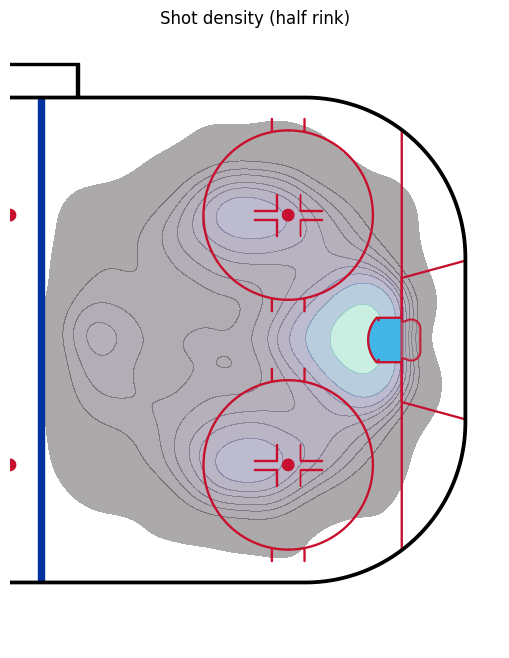

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sportypy.surfaces.hockey import NHLRink

# prepare shot coords (absolute x for one half)
x = pd.to_numeric(shots_non_flyers['details_xCoord'], errors='coerce')
y = pd.to_numeric(shots_non_flyers['details_yCoord'], errors='coerce')
mask = x.notna() & y.notna()
x = np.abs(x[mask]).to_numpy()
y = y[mask].to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))

# draw rink background using mplhockey; draw before plotting KDE so it's underneath
rink = NHLRink()               # you can pass theme='dark' or units='m' etc.
rink.draw(ax=ax, display_range='ozone')  # display_range can focus on a zone/half; optional. 

# overlay KDE with transparency; set zorder higher than rink so KDE is on top
sns.kdeplot(
    x=x,
    y=y,
    fill=True,
    cmap="mako",
    clip=((0, 100), (-42.5, 42.5)),
    bw_method=None,
    thresh=0.05,
    levels=10,
    ax=ax,
    alpha=0.35,   # make KDE more transparent (0.0 transparent, 1.0 opaque)
    zorder=5
)

# optional: overlay raw points above KDE
#ax.scatter(x, y, s=8, color='k', alpha=0.25, zorder=6)

ax.set_title("Shot density (half rink)")
plt.show()

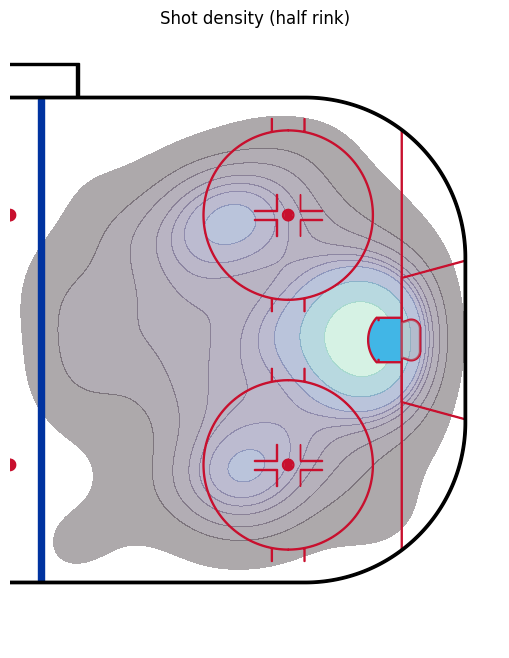

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sportypy.surfaces.hockey import NHLRink

# prepare shot coords (absolute x for one half)
x = pd.to_numeric(shots_flyers['details_xCoord'], errors='coerce')
y = pd.to_numeric(shots_flyers['details_yCoord'], errors='coerce')
mask = x.notna() & y.notna()
x = np.abs(x[mask]).to_numpy()
y = y[mask].to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))

# draw rink background using mplhockey; draw before plotting KDE so it's underneath
rink = NHLRink()               # you can pass theme='dark' or units='m' etc.
rink.draw(ax=ax, display_range='ozone')  # display_range can focus on a zone/half; optional. 

# overlay KDE with transparency; set zorder higher than rink so KDE is on top
sns.kdeplot(
    x=x,
    y=y,
    fill=True,
    cmap="mako",
    clip=((0, 100), (-42.5, 42.5)),
    bw_method=None,
    thresh=0.05,
    levels=10,
    ax=ax,
    alpha=0.35,   # make KDE more transparent (0.0 transparent, 1.0 opaque)
    zorder=5
)

# optional: overlay raw points above KDE
#ax.scatter(x, y, s=8, color='k', alpha=0.25, zorder=6)

ax.set_title("Shot density (half rink)")
plt.show()